## Bài tập thực hành 4 - 2026

Bài thực hành 4 - 2026

Link google colab: https://drive.google.com/file/d/1OAZK08O3AYoNvmbq7JIBg5Oknp6cJgzn/view?usp=sharing

---
### Thông tin sinh viên
- **MSSV**: 24521901
- **Họ và tên**: Trần Quang Trường
---


Để truy cập tập dữ liệu, ta sẽ mount tới Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import các thư viện cần thiết


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from google.colab.patches import cv2_imshow

In [8]:
img_path = '/content/drive/MyDrive/[CS231.Q21.KHTN] - Computer Vision 01/rice.png'


In [4]:
def drawHist(x):
    hist = cv2.calcHist([x], [0], None, [256], [0, 256])
    plt.plot(hist)
    plt.xlim([0, 256])
    plt.legend(('histogram'), loc = 'upper left')
    plt.show()

In [6]:
def globalThresholding(img, thres=127):
    img_rst = img.copy()
    for i in range(img.shape[0]):
      for j in range(img.shape[1]):
        if img_rst[i][j] < thres:
          img_rst[i][j] = 255
        else:
          img_rst[i][j] = 0
    return img_rst

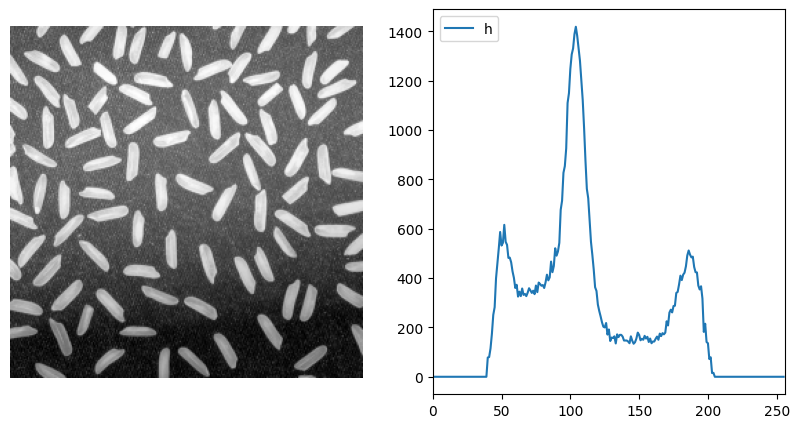

In [9]:
image=cv2.imread(img_path,0)
#image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

# Vẽ hình ảnh
plt.subplot(1, 2, 1)  # 1 hàng, 2 cột, subplot 1
plt.imshow(image, cmap=plt.cm.gray)
plt.axis('off')

# Vẽ biểu đồ
plt.subplot(1, 2, 2)  # 1 hàng, 2 cột, subplot 2
drawHist(image)

plt.show()

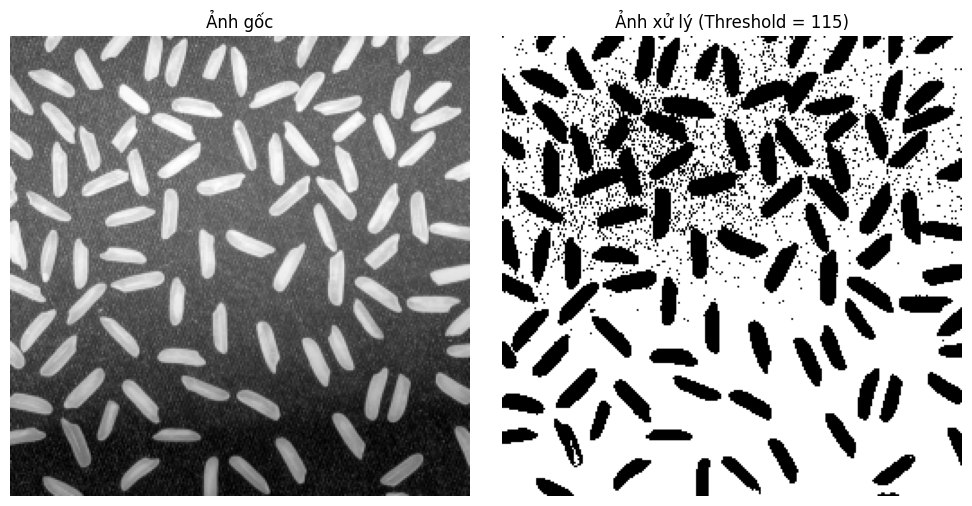

In [66]:
pic_threshold = 115

# Tạo subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

img= cv2.imread(img_path,0)
img_globalThreshold = globalThresholding(img, pic_threshold )

#Show ảnh gốc
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Ảnh gốc')
axes[0].axis('off')

#Ảnh qua xử lý
axes[1].imshow(img_globalThreshold, cmap='gray')
axes[1].set_title(f'Ảnh xử lý (Threshold = {pic_threshold})' )
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [69]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

img = cv2.imread(img_path, 0)

blur = cv2.GaussianBlur(img, (5, 5), 0)

_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

h, w = clean.shape
visited = np.zeros((h, w), dtype=bool)

directions = [
    (-1, -1), (-1, 0), (-1, 1),
    ( 0, -1),          ( 0, 1),
    ( 1, -1), ( 1, 0), ( 1, 1)
]

count = 0
result = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

for i in range(h):
    for j in range(w):
        if clean[i, j] == 255 and not visited[i, j]:
            q = deque()
            q.append((i, j))
            visited[i, j] = True

            pixels = []
            min_x, min_y = j, i
            max_x, max_y = j, i

            while q:
                x, y = q.popleft()
                pixels.append((x, y))

                min_x = min(min_x, y)
                min_y = min(min_y, x)
                max_x = max(max_x, y)
                max_y = max(max_y, x)

                for dx, dy in directions:
                    nx, ny = x + dx, y + dy
                    if 0 <= nx < h and 0 <= ny < w:
                        if clean[nx, ny] == 255 and not visited[nx, ny]:
                            visited[nx, ny] = True
                            q.append((nx, ny))

            area = len(pixels)

            if area >= 20:
                count += 1
                cv2.rectangle(result, (min_x, min_y), (max_x, max_y), (0, 255, 0), 1)
                cv2.putText(result, str(count), (min_x, min_y - 3),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0, 255, 0), 1)

print("So hat gao =", count)


So hat gao = 85
